#### Функции:

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io.wavfile import write

output_dir = "files/lab02"
fs = 44100

def generate_signal(A, f0, h, t):
    s = np.zeros_like(t)
    for Ai, hi in zip(A, h):
        s += Ai * np.sin(2 * np.pi * hi * f0 * t)
    return s

def my_fft(x):
    N_len = len(x)
    if N_len <= 1: return x
    even = my_fft(x[0::2])
    odd = my_fft(x[1::2])
    T = [np.exp(-2j * np.pi * k / N_len) * odd[k] for k in range(N_len // 2)]
    return np.array([even[k] + T[k] for k in range(N_len // 2)] + 
                    [even[k] - T[k] for k in range(N_len // 2)])
    
import numpy as np

def freqz(b, a=1, worN=512):
    w = np.linspace(0, np.pi, worN)
    h_freq = np.zeros(worN, dtype=complex)
    a = np.atleast_1d(a)
    for i, freq_val in enumerate(w):
        k_b = np.arange(len(b))
        num = np.sum(b * np.exp(-1j * freq_val * k_b))
        k_a = np.arange(len(a))
        den = np.sum(a * np.exp(-1j * freq_val * k_a))
        h_freq[i] = num / den   
    return w, h_freq

def firwin(numtaps, cutoff, window='blackman', fs=1.0):
    M = numtaps
    n = np.arange(M) - (M - 1) / 2
    f1, f2 = cutoff[0], cutoff[1]
    w1 = 2 * f1 / fs
    w2 = 2 * f2 / fs
    h_d = w2 * np.sinc(w2 * n) - w1 * np.sinc(w1 * n)
    idx = np.arange(M)
    if window == 'blackman':
        w_n = 0.42 - 0.5 * np.cos(2 * np.pi * idx / (M - 1)) + 0.08 * np.cos(4 * np.pi * idx / (M - 1))
    elif window == 'hamming':
        w_n = 0.54 - 0.46 * np.cos(2 * np.pi * idx / (M - 1))
    elif window == 'hanning':
        w_n = 0.5 * (1 - np.cos(2 * np.pi * idx / (M - 1)))
    else:
        w_n = np.ones(M)
    h = h_d * w_n
    f_center = (f1 + f2) / 2
    gain = np.abs(np.sum(h * np.exp(-2j * np.pi * f_center * n / fs)))
    if gain > 1e-10:
        h /= gain
    return h

def apply_fir(x_in, h_coeffs):
    N = len(h_coeffs)
    L = len(x_in)
    y = np.zeros(L)
    for n in range(L):
        for k in range(N):
            if n - k >= 0:
                y[n] += h_coeffs[k] * x_in[n - k]
    return y

def iir_narrowband(f0, bw, fs):
    f_norm = f0 / fs
    bw_norm = bw / fs
    R = 1 - 3 * bw_norm
    cos_2pi_f = np.cos(2 * np.pi * f_norm)
    num = 1 - 2 * R * cos_2pi_f + R**2
    den = 2 - 2 * cos_2pi_f
    K = num / den
    a0_m = 1 - K
    a1_m = 2 * (K - R) * cos_2pi_f
    a2_m = R**2 - K
    b1_m = 2 * R * cos_2pi_f
    b2_m = -R**2
    b = np.array([a0_m, a1_m, a2_m])
    a = np.array([1.0, -b1_m, -b2_m])
    return b, a

def apply_iir(x_in, b, a):
    M = len(b)
    N = len(a)
    L = len(x_in)
    y = np.zeros(L)
    for n in range(L):
        for i in range(M):
            if n - i >= 0:
                y[n] += b[i] * x_in[n - i]
        for j in range(1, N):
            if n - j >= 0:
                y[n] -= a[j] * y[n - j]
        y[n] /= a[0]
    return y

def draw_plot(x_data, y_data, title, color='tab:blue', x_lim=None):
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(x_data, y_data, color=color, linewidth=2)
    plt.title(title, fontsize=18, pad=8)
    plt.grid(True, alpha=0.5)
    plt.tick_params(axis='both', labelsize=8) 
    if x_lim is not None:
        plt.xlim(0, x_lim)
    plt.gca().locator_params(axis='both', nbins=10)
    plt.subplots_adjust(left=0.04, right=0.96, top=0.96, bottom=0.04)
    plt.show()
    
def draw_comparison_plot(x_vals, y_clean, y_noisy, title, x_lim=None):
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(x_vals, y_clean, color='black', linewidth=2, label='Original', alpha=0.5)
    plt.plot(x_vals, y_noisy, color='tab:red', linewidth=2, label='Noisy')
    plt.title(title, fontsize=18, pad=8)
    plt.grid(True, alpha=0.5)
    plt.tick_params(axis='both', labelsize=8)
    if x_lim is not None:
        plt.xlim(0, x_lim)
    plt.gca().locator_params(axis='both', nbins=10)
    plt.subplots_adjust(left=0.04, right=0.96, top=0.9, bottom=0.1)
    plt.show()
    
def draw_characteristics(f, m, p, title_m, title_p, x_lim=10000):
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(f, m, color='tab:red', linewidth=2)
    plt.title(title_m, fontsize=18)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_lim)
    plt.subplots_adjust(left=0.04, right=0.96)
    plt.show()
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(f, p, color='tab:red', linewidth=2)
    plt.title(title_p, fontsize=18)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_lim)
    plt.subplots_adjust(left=0.04, right=0.96)
    plt.show()

def save_wav(name, data):
    norm = data / np.max(np.abs(data))
    path = os.path.join(output_dir, name)
    write(path, fs, (norm * 32767).astype(np.int16))


#### Исходный график сигнала:

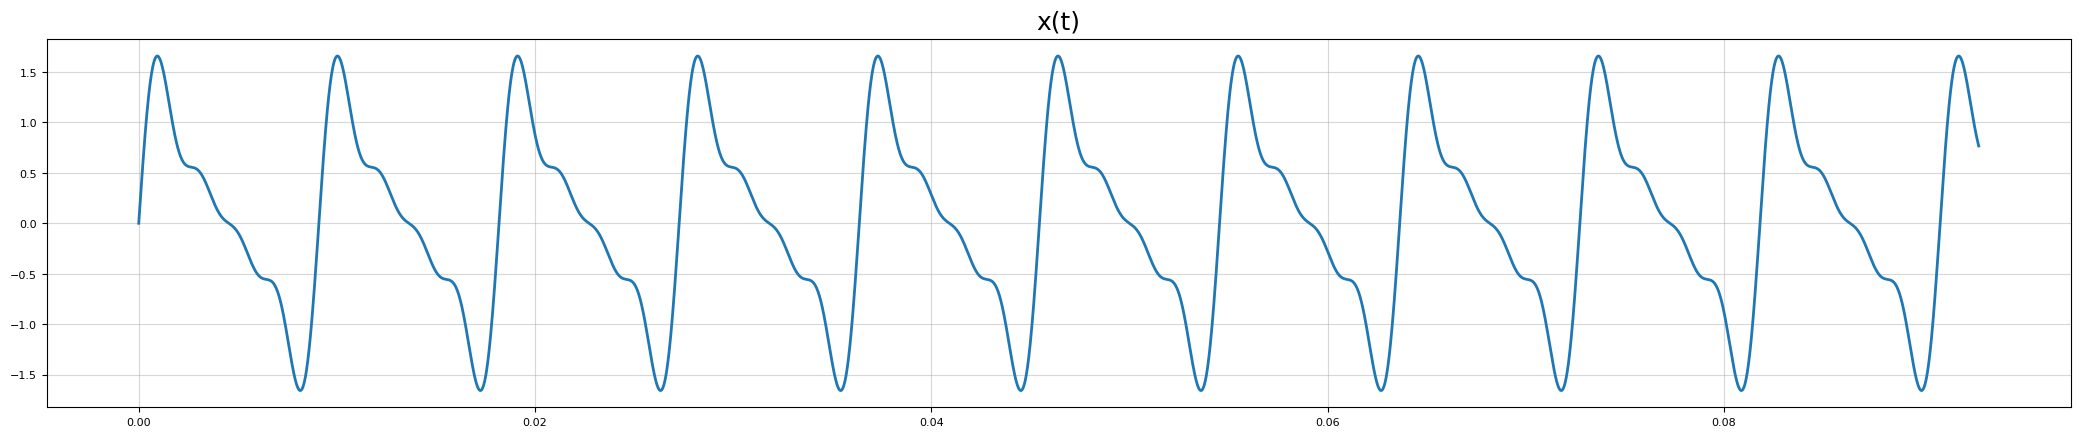

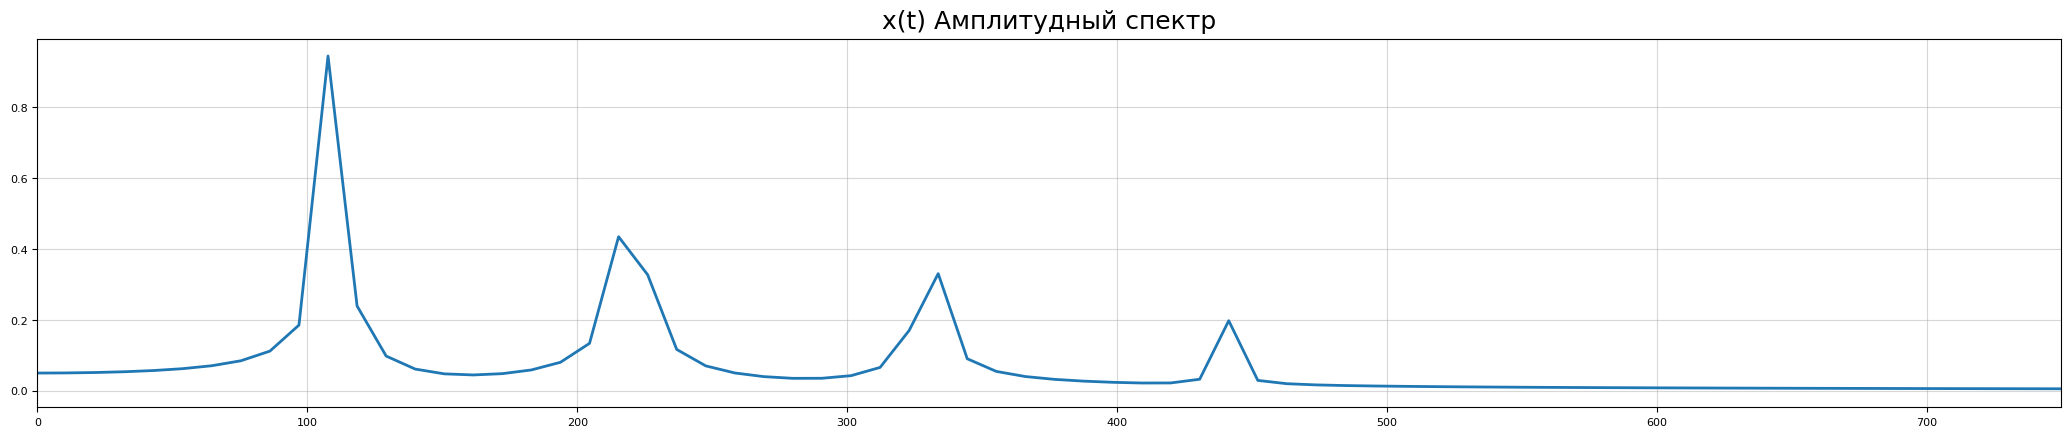

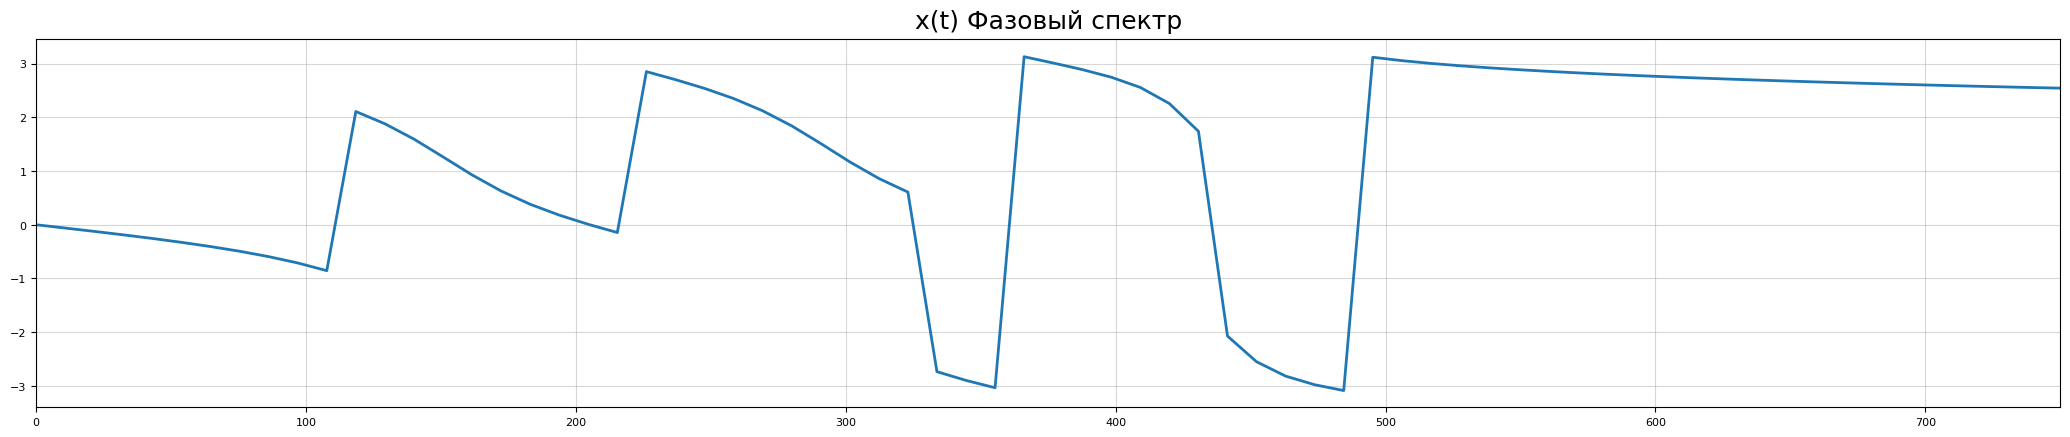

In [146]:
N_plot = 4096
t_plot = np.arange(N_plot) / fs
A_x, f0_x, h_x = [1, 0.6, 0.4, 0.2], 110, [1, 2, 3, 4]

x = generate_signal(A_x, f0_x, h_x, t_plot)
freq = np.arange(N_plot) * fs / N_plot
X_fft = my_fft(x)
mag = 2 * np.abs(X_fft[:N_plot//2]) / N_plot
phase = np.angle(X_fft[:N_plot//2])

draw_plot(t_plot, x, "x(t)")
draw_plot(freq[:N_plot//2], mag, "x(t) Амплитудный спектр", x_lim=750)
draw_plot(freq[:N_plot//2], phase, "x(t) Фазовый спектр", x_lim=750)

#### График сигнала с добавлением шума:

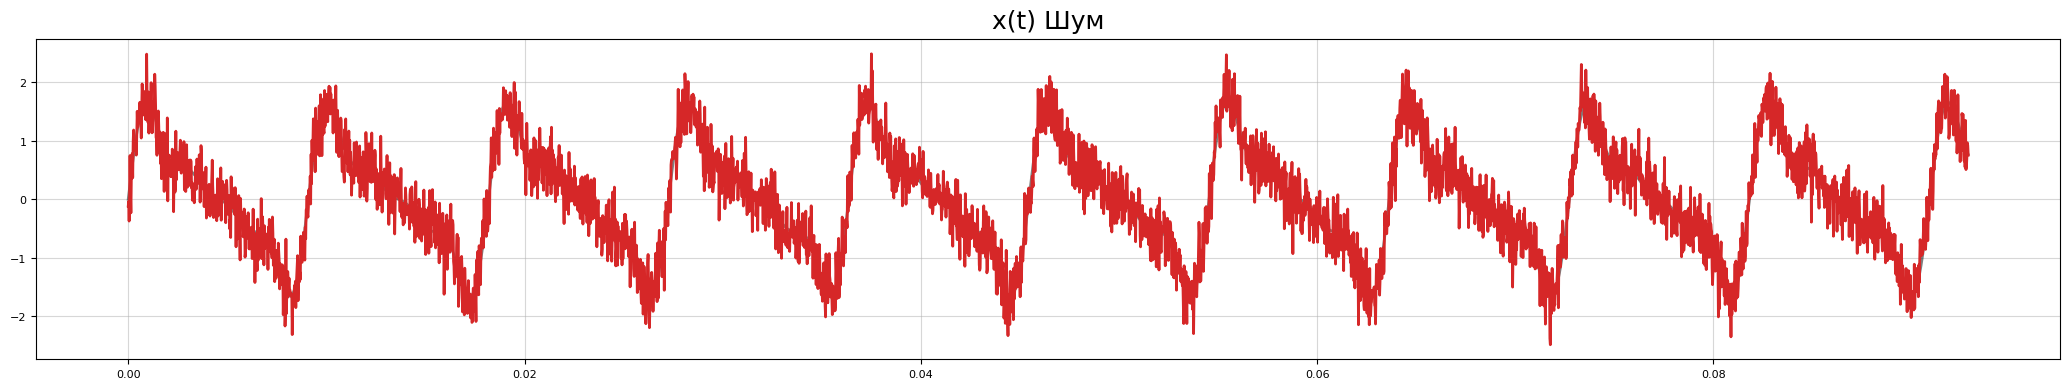

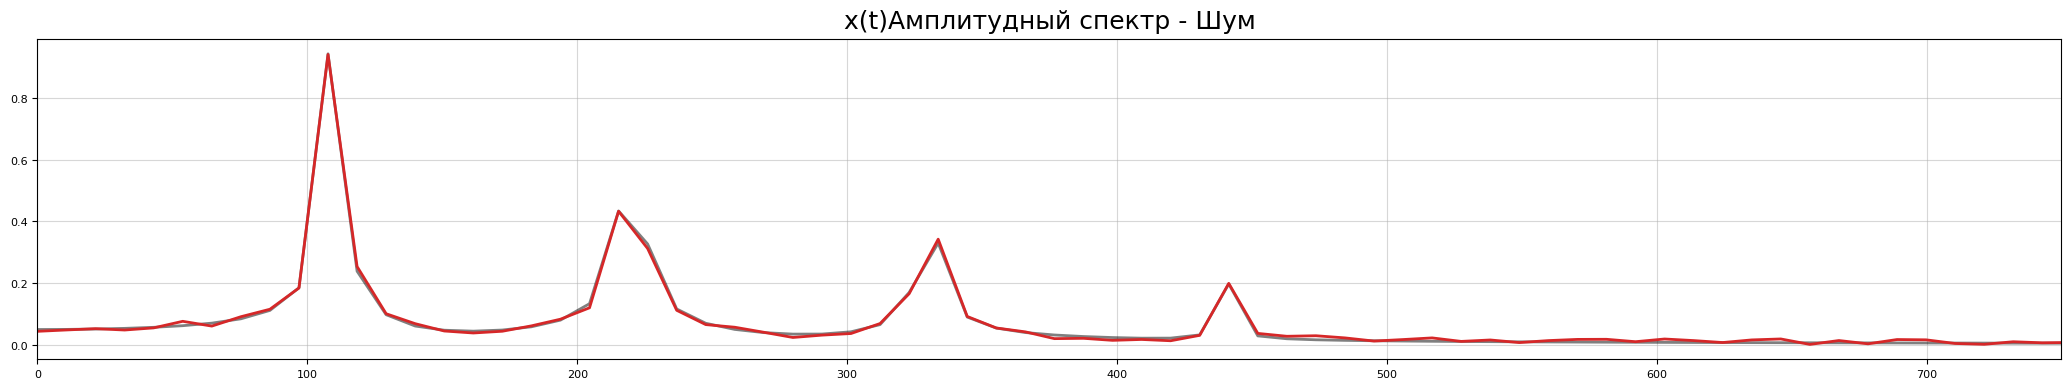

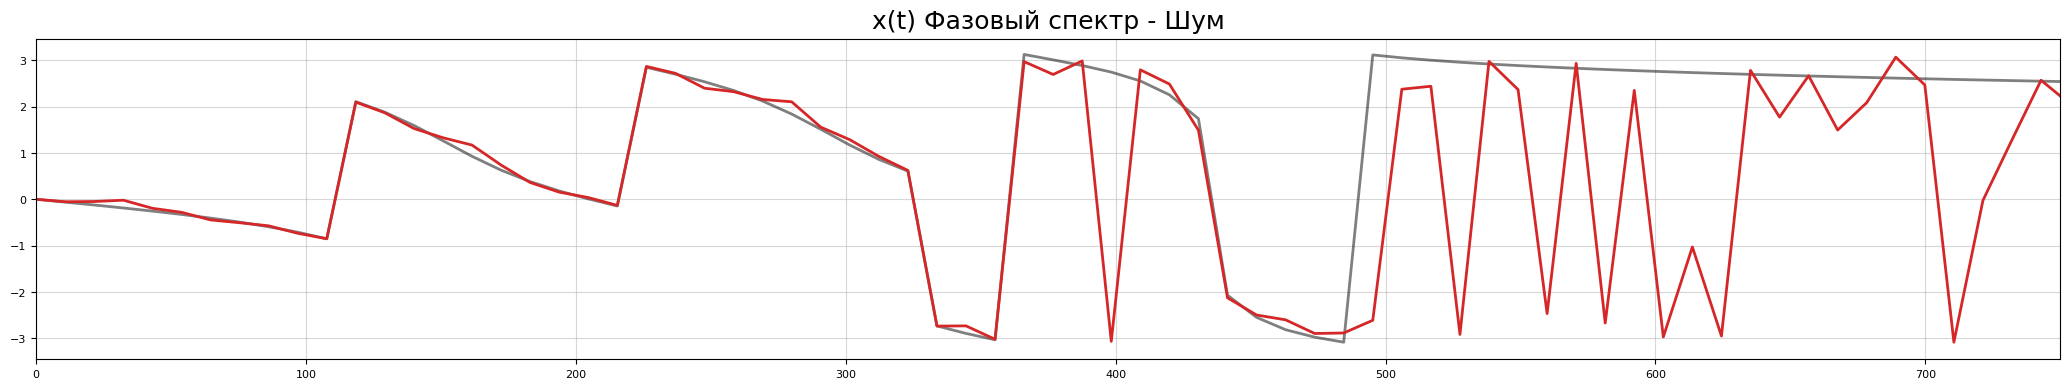

In [147]:
noise = 0.3 * np.random.normal(size=N_plot)
x_noisy = x + noise

X_fft_noisy = my_fft(x_noisy)
mag_noisy = 2 * np.abs(X_fft_noisy[:N_plot//2]) / N_plot
phase_noisy = np.angle(X_fft_noisy[:N_plot//2])

draw_comparison_plot(t_plot, x, x_noisy, "x(t) Шум")
draw_comparison_plot(freq[:N_plot//2], mag, mag_noisy, "x(t)Амплитудный спектр - Шум", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_noisy, "x(t) Фазовый спектр - Шум", x_lim=750)

#### Однородный фильтр:

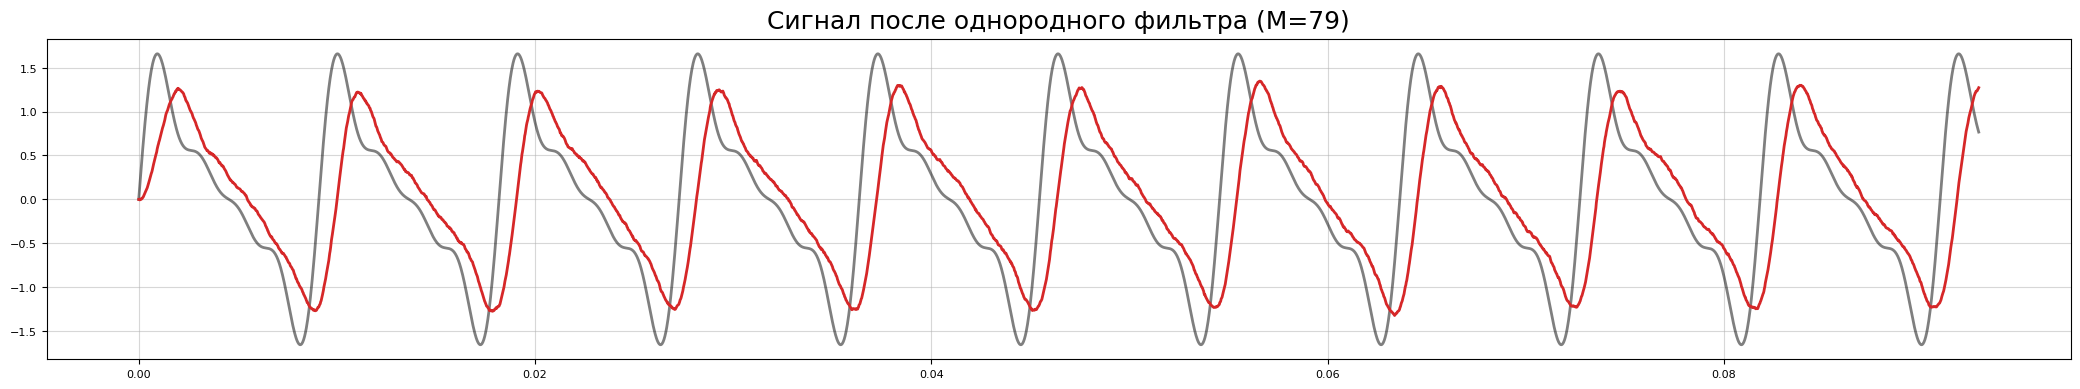

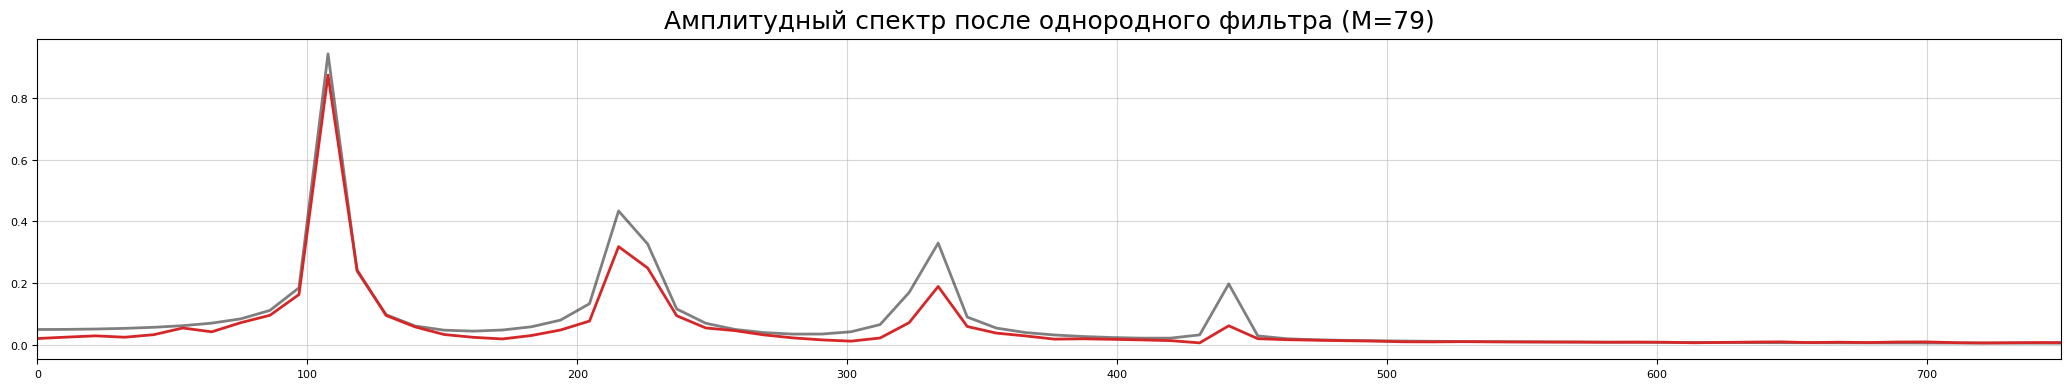

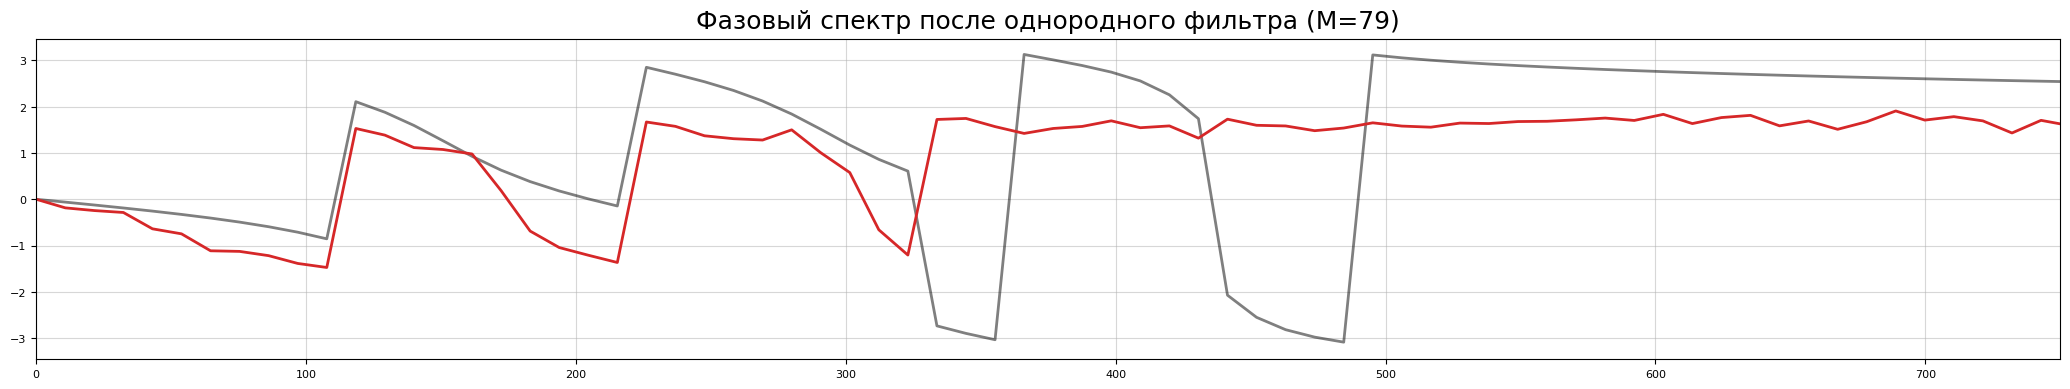

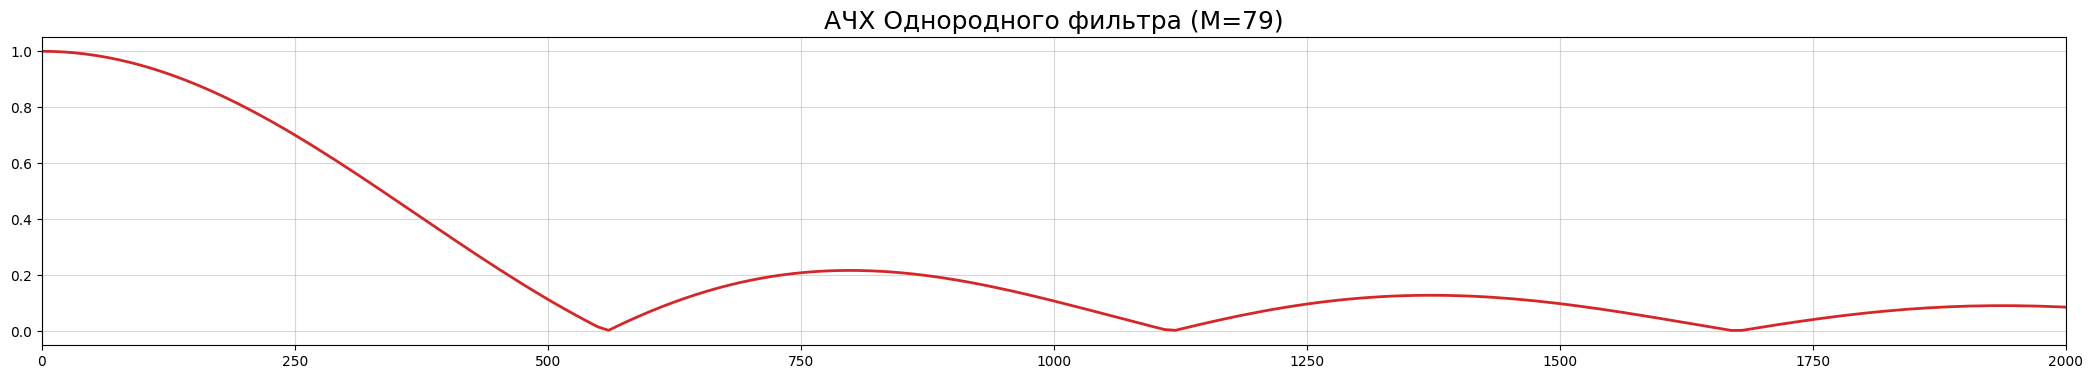

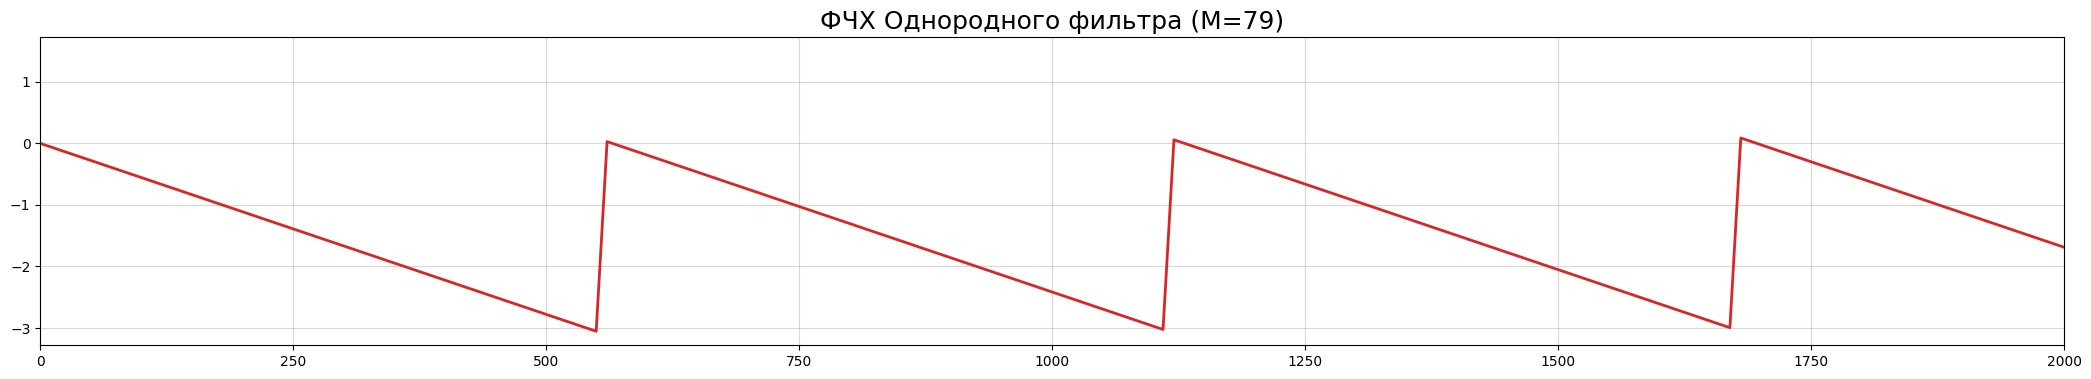

In [148]:
M = 79

x_padded = np.pad(x_noisy, (M, 0), mode='constant')
y_filtered = np.zeros_like(x_padded)

for n in range(M, len(x_padded)):
    y_filtered[n] = y_filtered[n-1] + (x_padded[n] - x_padded[n-M]) / M

y_final = y_filtered[M:] 
Y_fft = my_fft(y_final)
mag_filtered = 2 * np.abs(Y_fft[:N_plot//2]) / N_plot
phase_filtered = np.angle(Y_fft[:N_plot//2])

h = np.ones(M) / M
w, h_freq = freqz(h, worN=N_plot//2)
response_mag = np.abs(h_freq)
response_phase = np.angle(h_freq)
freq_hz = w * fs / (2 * np.pi)

draw_comparison_plot(t_plot, x, y_final, f"Сигнал после однородного фильтра (M={M})")
draw_comparison_plot(freq[:N_plot//2], mag, mag_filtered, f"Амплитудный спектр после однородного фильтра (M={M})", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_filtered, f"Фазовый спектр после однородного фильтра (M={M})", x_lim=750)
draw_characteristics(freq_hz, response_mag, response_phase, f"АЧХ Однородного фильтра (M={M})", f"ФЧХ Однородного фильтра (M={M})", x_lim=2000)

#### КИХ Оконный филтр:

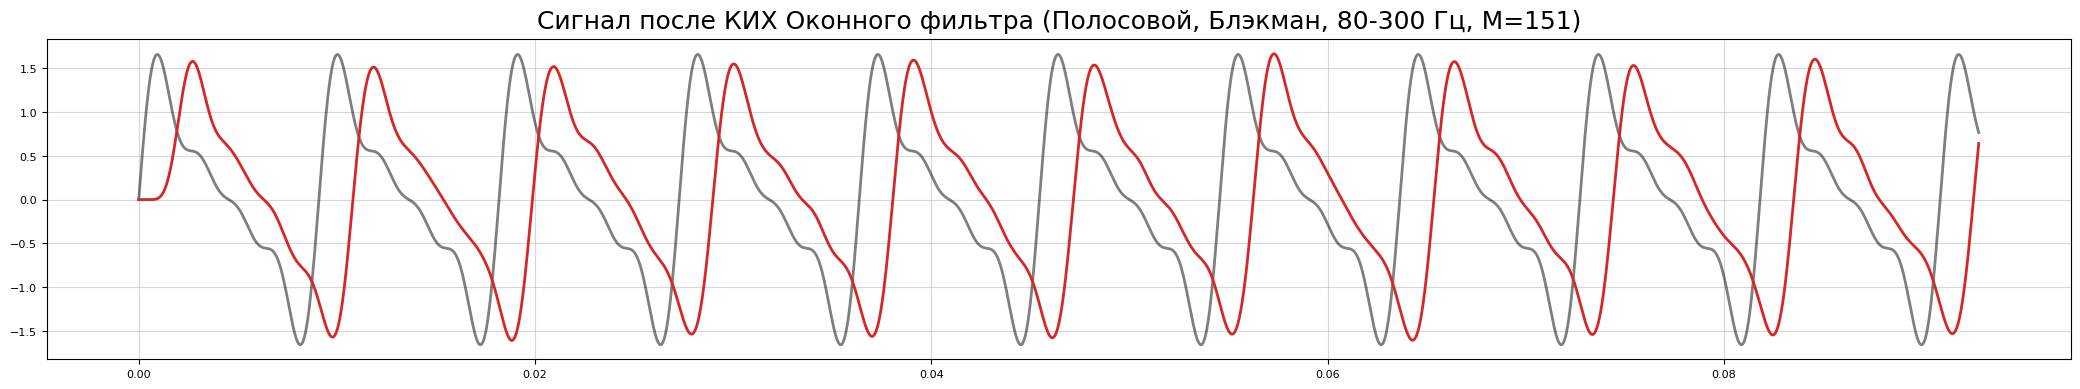

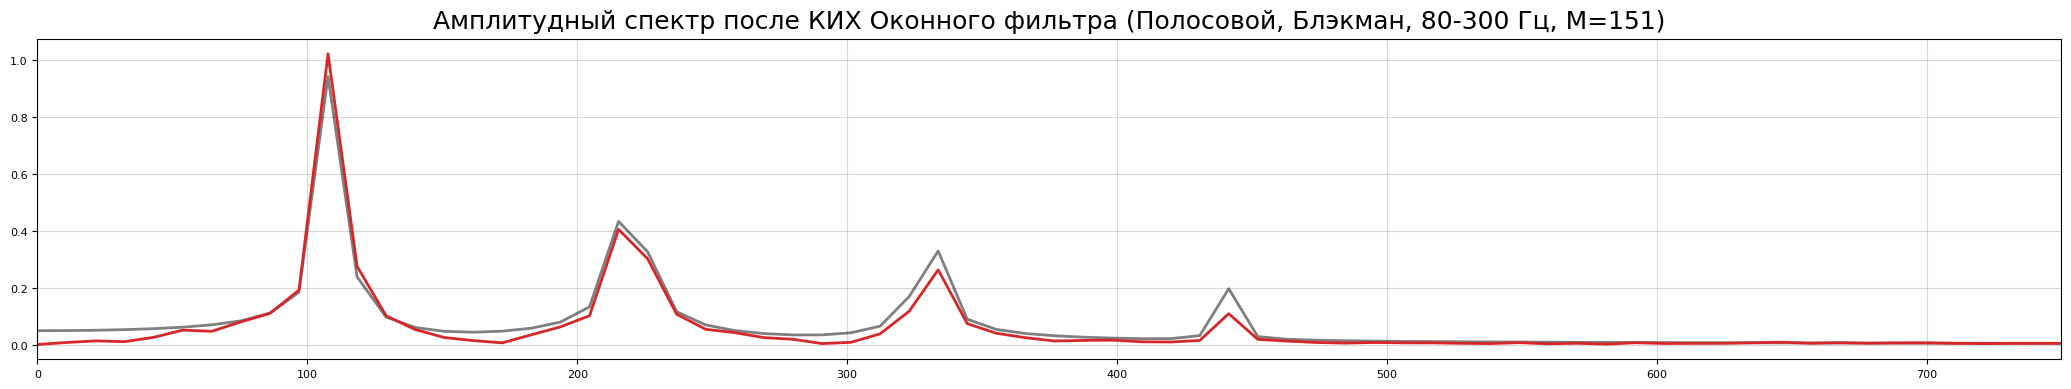

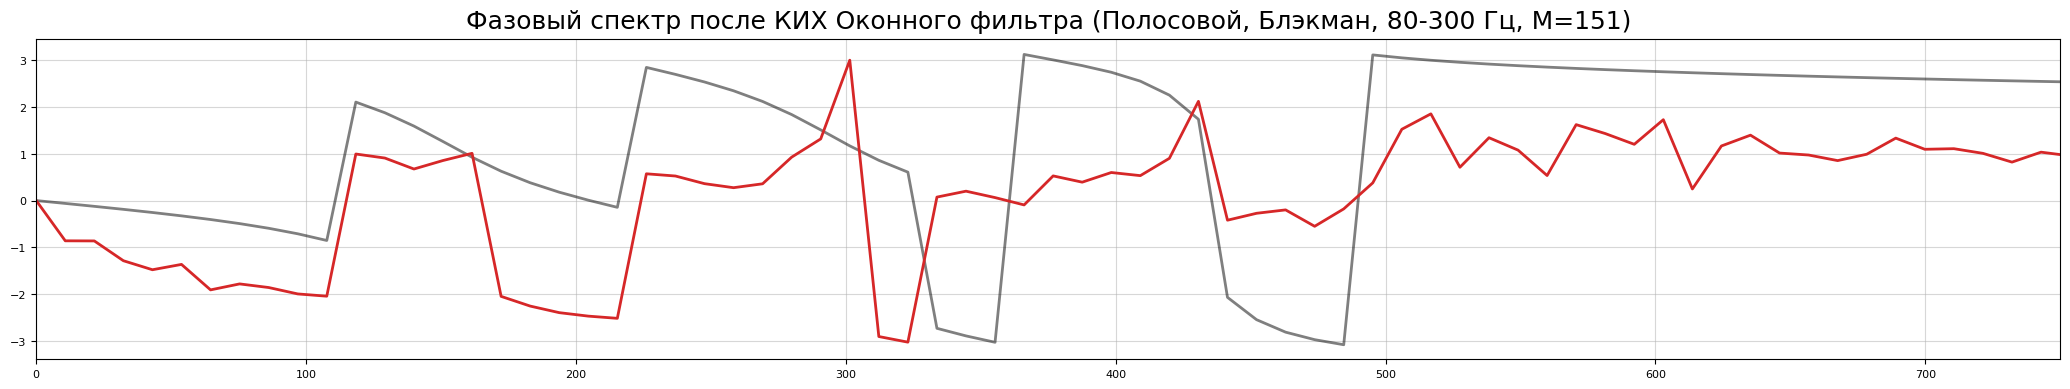

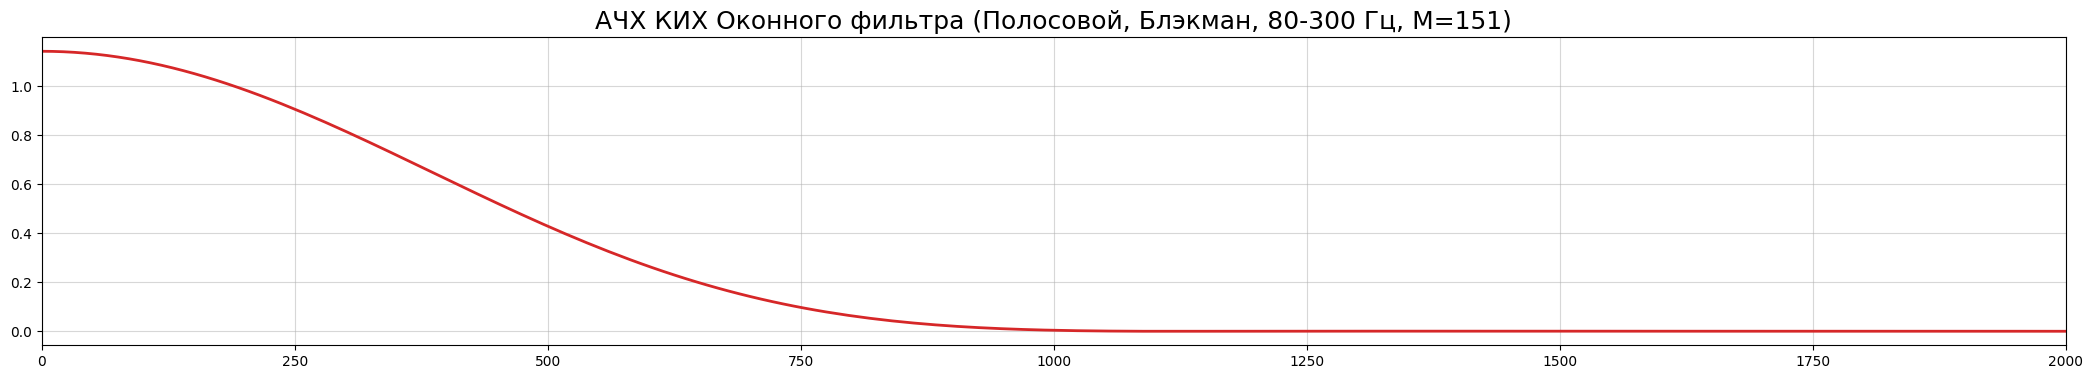

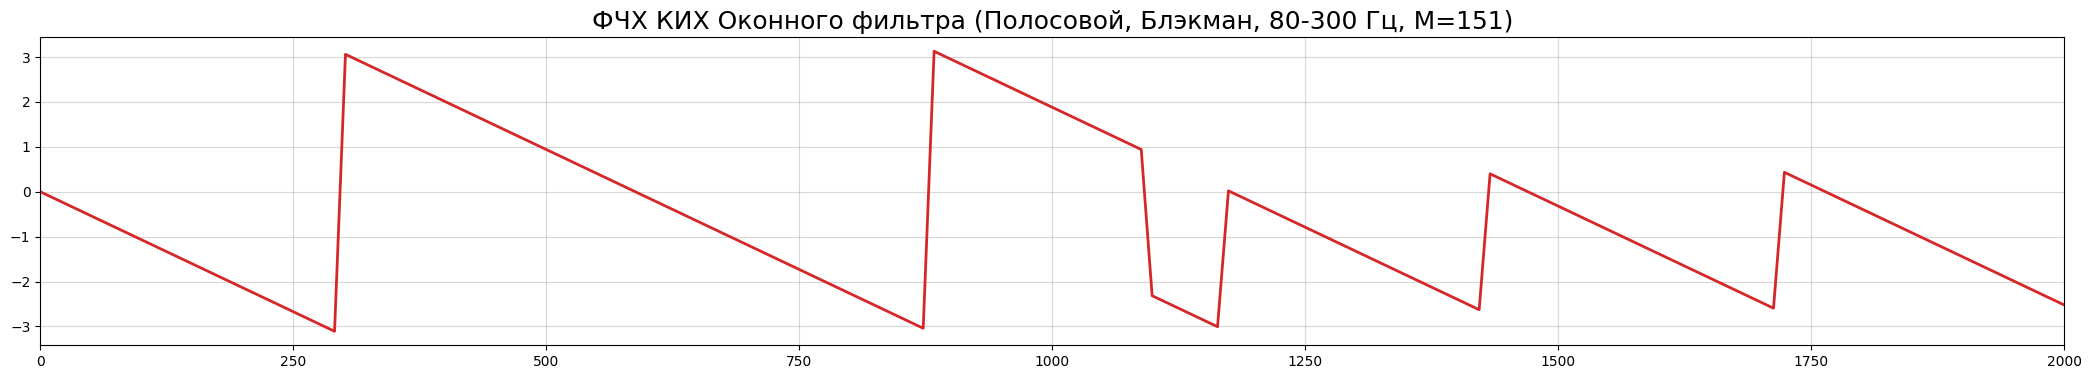

In [149]:
M_fir = 151
f_low = 80
f_high = 300

h_fir = firwin(M_fir, [f_low, f_high], window='blackman', fs=fs)

y_fir = apply_fir(x_noisy, h_fir)
Y_fft_fir = my_fft(y_fir)
mag_fir = 2 * np.abs(Y_fft_fir[:N_plot//2]) / N_plot
phase_fir = np.angle(Y_fft_fir[:N_plot//2])

w, h_freq = freqz(h_fir, worN=N_plot//2)
response_mag_fir = np.abs(h_freq)
response_phase_fir = np.angle(h_freq)
freq_hz_fir = w * fs / (2 * np.pi)

draw_comparison_plot(t_plot, x, y_fir, f"Сигнал после КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})")
draw_comparison_plot(freq[:N_plot//2], mag, mag_fir, f"Амплитудный спектр после КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_fir, f"Фазовый спектр после КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})", x_lim=750)
draw_characteristics(freq_hz_fir, response_mag_fir, response_phase_fir,
                     f"АЧХ КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})",
                     f"ФЧХ КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})", x_lim=2000)

#### БИХ Фильтр:

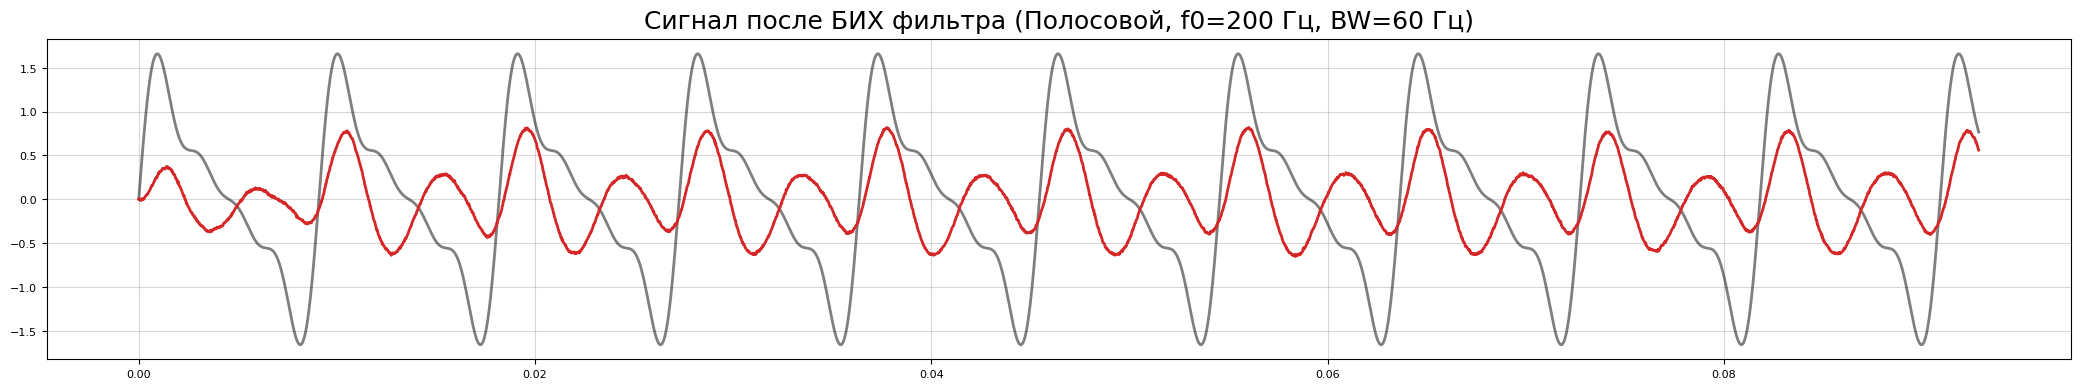

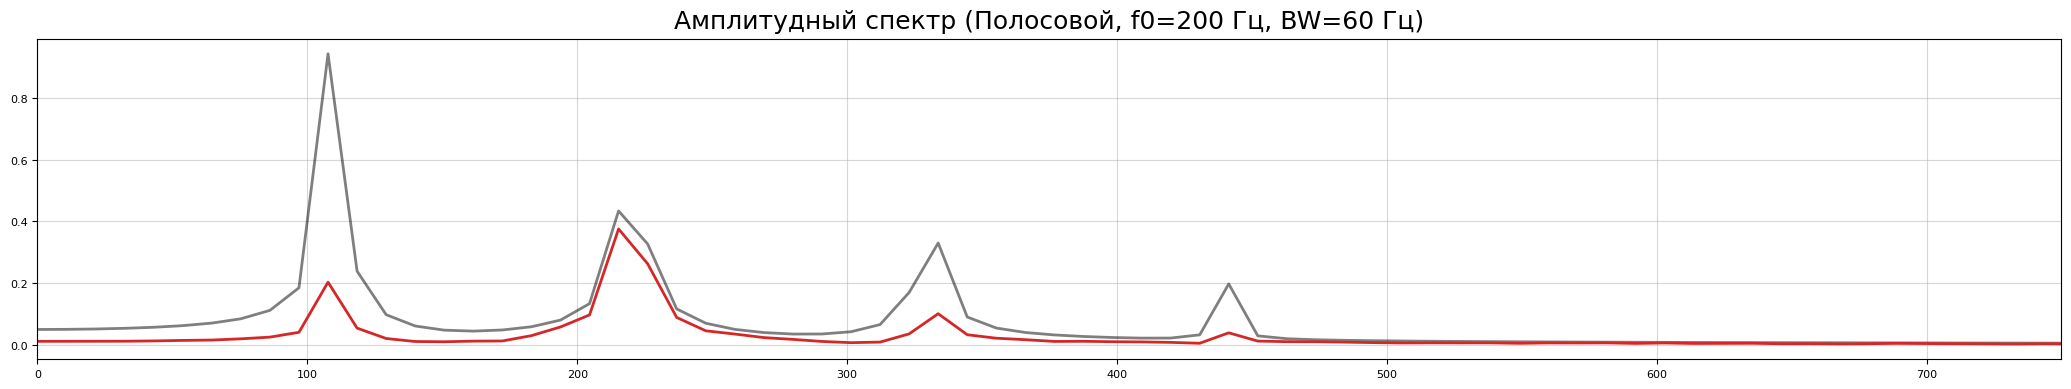

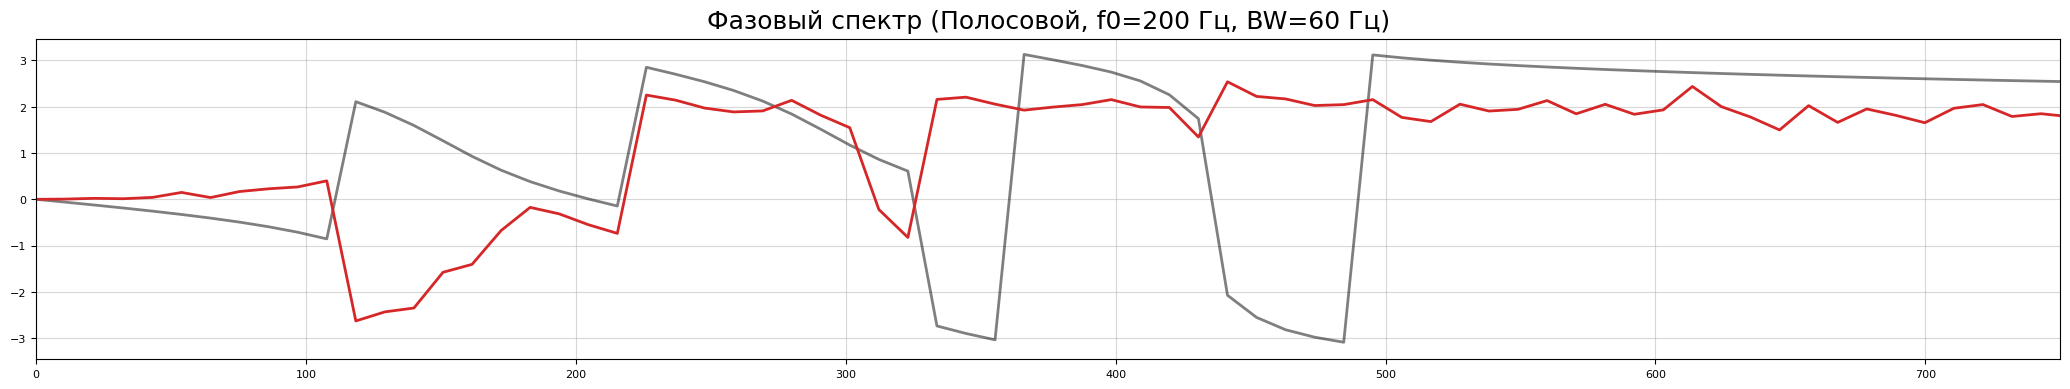

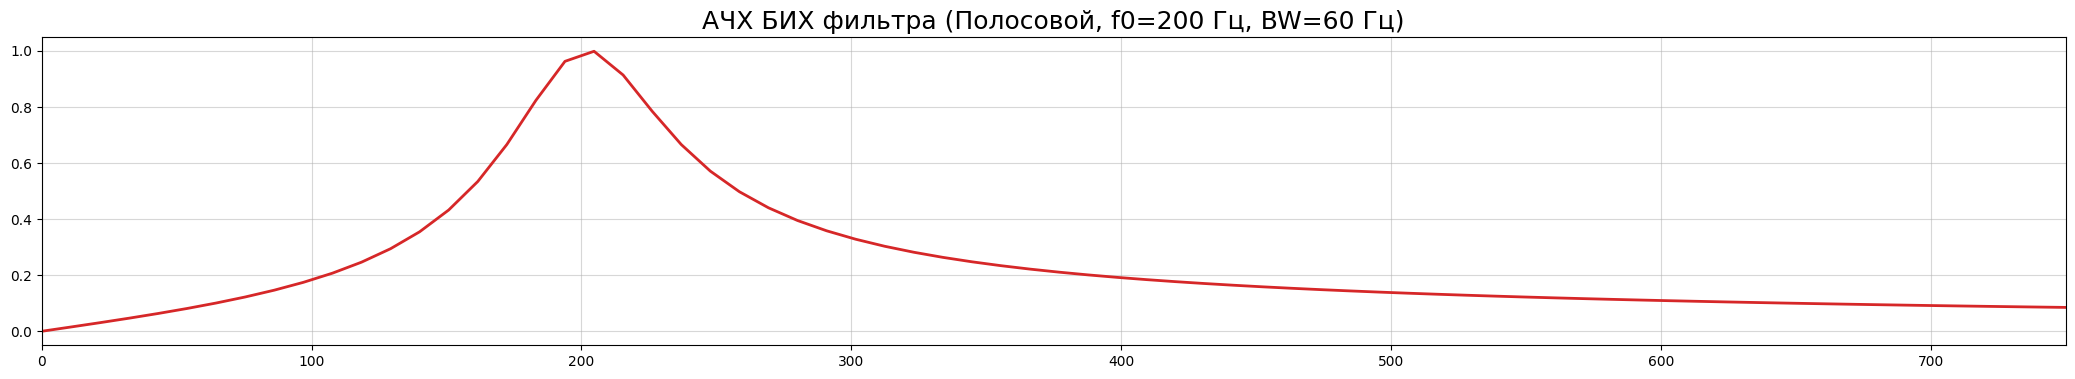

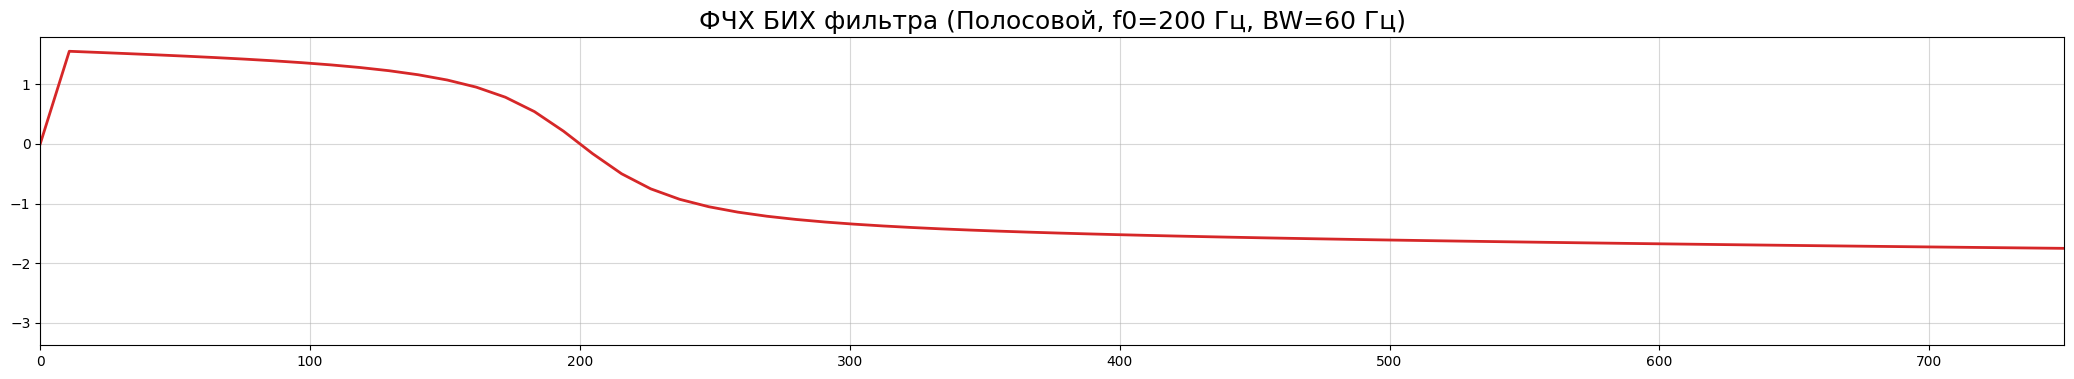

In [150]:
f0 = 200
bw = 60
f_low = f0 - bw/2
f_high = f0 + bw/2

b_iir, a_iir = iir_narrowband(f0, bw, fs)
y_iir = apply_iir(x_noisy, b_iir, a_iir)

Y_fft_iir = my_fft(y_iir)
mag_iir = 2 * np.abs(Y_fft_iir[:N_plot//2]) / N_plot
phase_iir = np.angle(Y_fft_iir[:N_plot//2])

w, h_freq = freqz(b_iir, a_iir, worN=N_plot//2)
response_mag_iir = np.abs(h_freq)
response_phase_iir = np.angle(h_freq)
freq_hz_iir = w * fs / (2 * np.pi)

draw_comparison_plot(t_plot, x, y_iir, f"Сигнал после БИХ фильтра (Полосовой, f0={f0} Гц, BW={bw} Гц)")
draw_comparison_plot(freq[:N_plot//2], mag, mag_iir, f"Амплитудный спектр (Полосовой, f0={f0} Гц, BW={bw} Гц)", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_iir, f"Фазовый спектр (Полосовой, f0={f0} Гц, BW={bw} Гц)", x_lim=750)
draw_characteristics(freq_hz_iir, response_mag_iir, response_phase_iir, 
                     f"АЧХ БИХ фильтра (Полосовой, f0={f0} Гц, BW={bw} Гц)", 
                     f"ФЧХ БИХ фильтра (Полосовой, f0={f0} Гц, BW={bw} Гц)", x_lim=750)

#### Аудио:

In [151]:
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

duration_s = 5
t_audio = np.arange(int(fs * duration_s)) / fs

x_long = generate_signal(A_x, f0_x, h_x, t_audio)

noise_long = 0.3 * np.random.normal(size=len(t_audio))
x_noisy_long = x_long + noise_long

y_moving_avg = np.zeros_like(x_noisy_long)
M_val = 79
x_padded_long = np.pad(x_noisy_long, (M_val, 0), mode='constant')
for n in range(M_val, len(x_padded_long)):
    y_moving_avg[n-M_val] = (x_padded_long[n] - x_padded_long[n-M_val])
y_moving_avg = np.cumsum(y_moving_avg) / M_val

y_fir_long = apply_fir(x_noisy_long, h_fir)
y_iir_long = apply_iir(x_noisy_long, b_iir, a_iir)

save_wav("1-Clean.wav", x_long)
save_wav("2-Noisy.wav", x_noisy_long)
save_wav("3-FilterMovingAvg.wav", y_moving_avg)
save_wav("4-FilterFIR.wav", y_fir_long)
save_wav("5-FilterIIR.wav", y_iir_long)